### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True})
from astropy.constants import c, k_B, R_earth
import src.read_database as read_database
import src.map_properties as map_properties
import src.satellite_properties as satellite_properties
import src.store_FOV_indices as store_FOV_indices
import src.Friis as Friis
import src.power_3D_cube as power_3D_cube

%matplotlib inline   

### Read FM Transmitter Database 

In [2]:
n = str(input("Enter the number of countries to include"))

Enter the number of countries to includeAll


In [3]:
import os

directory_path = "./database/"

# List all files in the directory, excluding hidden files and directories
list_of_countries = [entry for entry in os.listdir(directory_path) if not entry.startswith('.')]
print(list_of_countries)


['Australia.csv', 'UK_final.csv', 'Netherlands.csv', 'South_Africa.csv', 'India.csv', 'Italy.csv', 'Canada.csv', 'updated_USA_file_final.csv', 'Tokyo.csv', 'updated_file_sweden.csv', 'Germany.csv', 'Brazil.csv']


In [4]:
df = read_database.read_FM_database(countries=read_database.get_countries(n))

### Define frequency range  

In [5]:
freq_range = read_database.get_freq_range()
import numpy as np




Please enter the minimum value of the frequency range (in MHz): 55
Please enter the maximum value of the frequency range (in MHz): 110
Please enter the resolution of the frequency (in MHz): 0.244


In [6]:
df = read_database.extract_common_freq(df, freq_range)


### Define resolution of the Healpy map

In [7]:
print('----------- Resolution of the map -----------')

# The default value of nside is 16
nside = int(input("Enter the NSIDE of the healpy map"))
npix, pix_array, phi, theta = map_properties.get_map(nside)

print(f"The number of pixels for the given NSIDE: {(hp.nside2npix(nside))}")
print(f"Approximate resolution in degrees for given nside {np.degrees(hp.nside2resol(nside)):.2f}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.2f} square degrees")

----------- Resolution of the map -----------
Enter the NSIDE of the healpy map16
The number of pixels for the given NSIDE: 3072
Approximate resolution in degrees for given nside 3.66
Pixel area: 13.43 square degrees


### Allocate pixel number to the Latitude and Longitude of each FM transmitter in the database

In [8]:
df, pixel_indices = read_database.allocate_pixel_num(nside, df)





### Define altitude of the satellite orbit 

In [9]:
altitudes = satellite_properties.get_altitudes()

Enter the minimum altitude of the satellite: 400
Enter the maximum altitude of the satellite: 36000
Enter number of data points : 3


### Calculation of Elevation angle

In [10]:
elev_angle = satellite_properties.calc_elev_angle(npix, phi, theta, altitudes)

/home/yogen14/Project/src/satellite_properties.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  elev_ang[k,i,j]=-(np.degrees(np.arctan((B-np.cos(np.radians(y_ang[i,j])))/np.sin(np.radians(y_ang[i,j])))))
/home/yogen14/Project/src/satellite_properties.py:41: RuntimeWarning: invalid value encountered in arccos
  y_ang[i,j]=(np.arccos(x_ang[i,j]))


### Define radiation pattern of the satellite antenna beam [optional]

In [11]:
beam = satellite_properties.get_beam_pattern("cos square", theta)
az = 0 # Assuming the satellite antenna beam to be symmetric across azimuth

###  Calculation of Field of view (FOV) and Radius of the FOV of the satellite

In [12]:
FOV = satellite_properties.calc_field_of_view(altitudes)

The Field of view of the satellite at a height of 400.00 km is 2.45 radians
The Field of view of the satellite at a height of 3794.73 km is 1.36 radians
The Field of view of the satellite at a height of 36000.00 km is 0.30 radians


In [13]:
Central_angle, Rad_of_FOV = satellite_properties.calc_central_angle(altitudes)
print(Central_angle,Rad_of_FOV)

The Radius of the Field of View for a height of 400.00 km in radians is 0.35
The Radius of the Field of View for a height of 3794.73 km in radians is 0.89
The Radius of the Field of View for a height of 36000.00 km in radians is 1.42
[0.34526318 0.89313372 1.41971764] [0.34526318 0.89313372 1.41971764]


# Create power cube 

In [14]:
disc = store_FOV_indices.get_disc(nside, phi, theta, Rad_of_FOV, pix_array)
print(np.shape(disc))

(3072, 3)


In [15]:
pix_common = store_FOV_indices.get_common_pix(pix_array, Rad_of_FOV, disc, df)
np.shape(pix_common)


(3072, 3)

In [16]:
found_common = store_FOV_indices.get_common_Tx(pixel_indices, pix_common, Rad_of_FOV)

## Plot Healpy map of beam-weighted FOV of a satellite overhead a particular location

<b> Transmitter locations from the FM Transmitter database and the received power at different altitudes has not been taken into account for these plots <b>

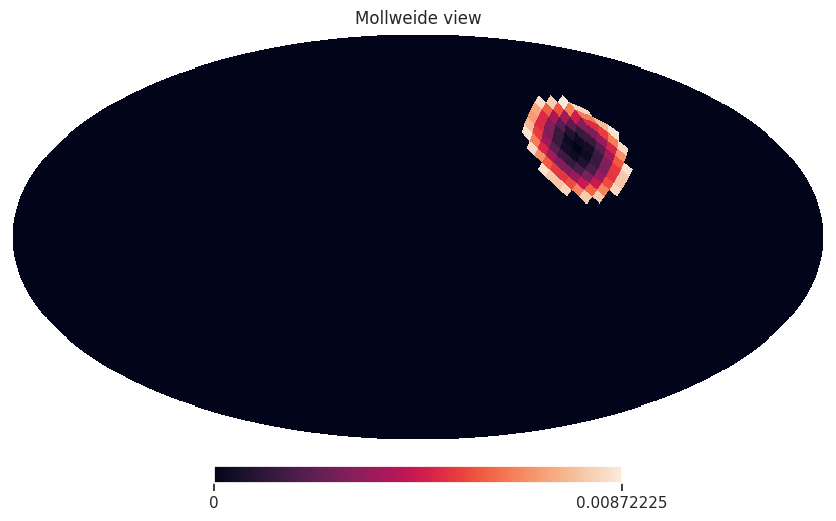

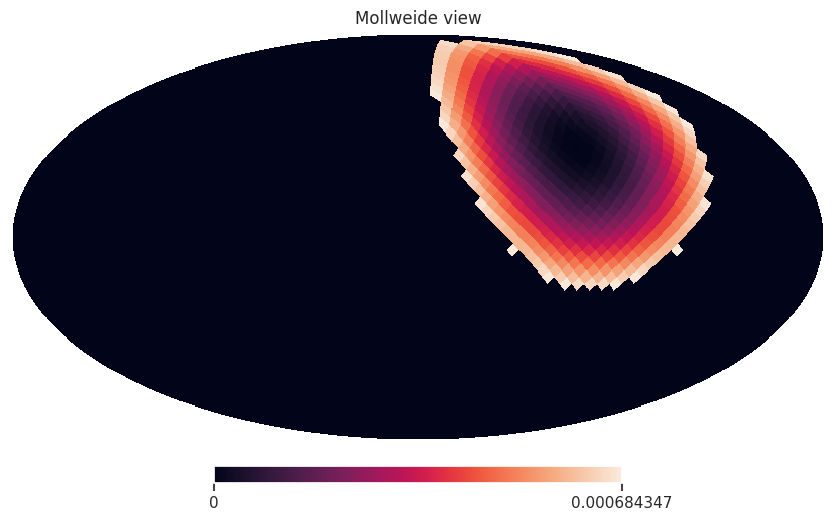

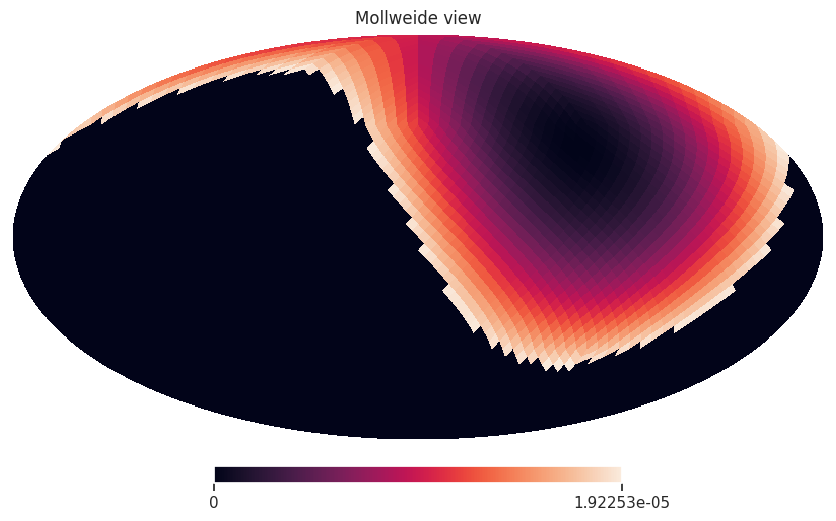

In [17]:
xx4=disc[686][0]  # For Hanle at an altitude of 400 km
xx5=disc[686][1]
xx6=disc[686][2]

y4=satellite_properties.get_beam_pattern("cos square", elev_angle[0,686,xx4])
y5=satellite_properties.get_beam_pattern("cos square", elev_angle[1,686,xx5])
y6=satellite_properties.get_beam_pattern("cos square", elev_angle[2,686,xx6])

data4= np.zeros(hp.nside2npix(nside))
data5= np.zeros(hp.nside2npix(nside))
data6= np.zeros(hp.nside2npix(nside))

data4[xx4]=y4
data5[xx5]=y5

data6[xx6]=y6

hp.mollview(data4,flip='geo')
hp.mollview(data5,flip='geo')
hp.mollview(data6,flip='geo')

In [18]:
Rx_Power_in_Kelvin = Friis.calc_Friis(df, altitudes)[2]

/home/yogen14/Project/src/Friis.py:30: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBm[j][i]= 10.*np.log10( Rx_Power[j][i])+30
/home/yogen14/Project/src/Friis.py:32: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBW[j][i]= 10.*np.log10( Rx_Power[j][i])


In [19]:
df_fov = power_3D_cube.get_dataframe_fov(Rx_Power_in_Kelvin, df, found_common, Rad_of_FOV, elev_angle)

In [20]:
power_output = power_3D_cube.get_power_output(npix, Rad_of_FOV, freq_range, df_fov)

## Plot Power Spectrum 

<b> The first index represents altitude of the satellite <b>\
<b> The second index represents location of the satellite(pixel number) <b>\
<b> The third index represents range of frequencies <b>

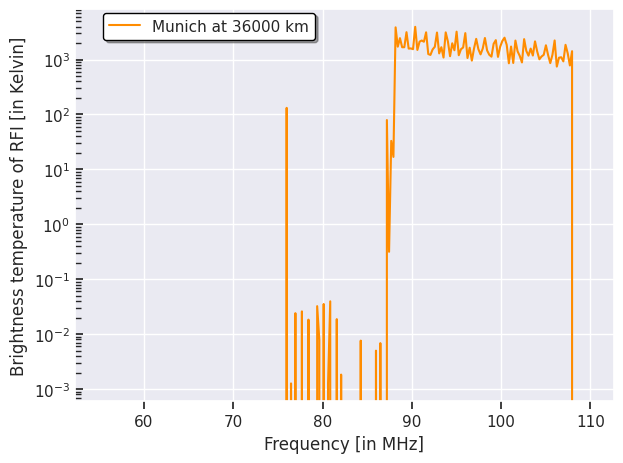

In [21]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})

plt.plot(freq_range,power_output[2,365,:], label='Munich at 36000 km', color='darkorange') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)


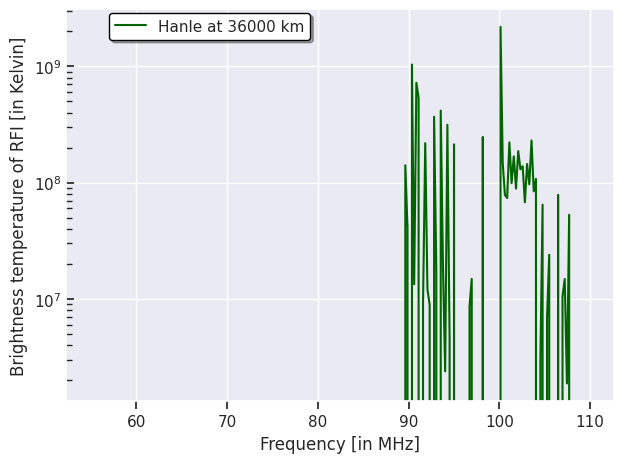

In [22]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})

plt.plot(freq_range,power_output[0,686,:], label='Hanle at 36000 km', color='darkgreen') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig("/home/sonia/Documents/RFI_PAPER/Hanle_36000_new.pdf")

In [23]:
num_of_rfi_chan=len(freq_range[power_output[0,13,:]!=0])
num_of_rfi_chan


#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)



#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=3 (Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=0 (Pacic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)




#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)

#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)





#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada,)

#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada,)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada,)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany,\n Canada)







#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany)

#NUM_OF_RFI_CHANNEL=13 (Pacific Ocean at 36000 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany)






#NUM_OF_RFI_CHANNEL=32 (Arctic Ocean at 36000 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=12 (Arctic Ocean at 3795 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA)

#NUM_OF_RFI_CHANNEL=12 (Pacific Ocean at 36000 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=2 (Paciic Ocean at 3795 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA)




#NUM_OF_RFI_CHANNEL=31 (Arctic Ocean at 36000 km (Tokyo)
#NUM_OF_RFI_CHANNEL=11 (Arctic Ocean at 3795 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo)

#NUM_OF_RFI_CHANNEL=10 (Pacific Ocean at 36000 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0(Paciic Ocean at 3795 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo)




57

In [24]:
rfi_band=244*num_of_rfi_chan # in kHz
rfi_band_inMHz=rfi_band*1e-3
rfi_band_inMHz

13.908

In [25]:
tot_band=freq_range[-1]-freq_range[0]
usable_band=tot_band-rfi_band_inMHz
usable_band


#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)



#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia )
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia )

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia 
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)




#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada)

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada,
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, 
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, )






#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA,, Germany)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany)

#USABLE_BW=51.828(Pacific Ocean at 36000 km (Tokyo, USA, Germany)
#USABLE_BW_CHANNEL=54.268(Pacifc Ocean at 3795 km (Tokyo, USA, Germany)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany)





#USABLE_BW=47.192(Arctic Ocean at 36000 km (Tokyo, USA)
#USABLE_BW_CHANNEL=52.072 (Arctic Ocean at 3795 km (Tokyo, USA)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA)

#USABLE_BW=52.072(Pacific Ocean at 36000 km (Tokyo, USA)
#USABLE_BW_CHANNEL=54.512(Pacifc Ocean at 3795 km (Tokyo, USA)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA)





#USABLE_BW=47.436(Arctic Ocean at 36000 km (Tokyo)
#USABLE_BW_CHANNEL=52.316 (Arctic Ocean at 3795 km (Tokyo)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo)

#USABLE_BW=52.56(Pacific Ocean at 36000 km (Tokyo)
#USABLE_BW_CHANNEL=55(Pacifc Ocean at 3795 km (Tokyo)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo)



40.99199999999995

In [26]:
time=1
FOM=time*usable_band
FOM

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 55.0
#---------------------------------------------------------------------------------------------------------

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia ) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia )34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia )53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia ) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia ) 55

#------------------------------------------------------------------------------------------------------------



#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany) 34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada,) 53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada ) 55

#---------------------------------------------------------------------------------------------------------------

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany) 34.50
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany) 53.048


#FOM=51.828(Pacific Ocean at 36000 km (Tokyo, USA, Germany) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany) 55

#---------------------------------------------------------------------------------------------------------------


#FOM=47.192(Arctic Ocean at 36000 km (Tokyo, USA,) 31.576
#FOM=52.072(Arctic Ocean at 3795 km (Tokyo, USA) 34.992
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA) 53.048


#FOM=52.072(Pacific Ocean at 36000 km (Tokyo, USA) 34.748
#FOM=54.512(Paciic Ocean at 3795 km (Tokyo, USA )34.748
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA) 55

#------------------------------------------------------------------------------------------------------------


#FOM=47.436(Arctic Ocean at 36000 km (Tokyo,) 47.192
#FOM=52.316(Arctic Ocean at 3795 km (Tokyo) 52.316
#FOM=55(Arctic Ocean at 400 km (Tokyo) 55


#FOM=52.56(Pacific Ocean at 36000 km (Tokyo) 52.316
#FOM=55(Paciic Ocean at 3795 km (Tokyo ) 54.756
#FOM=55(Pacific Ocean at 400 km (Tokyo) 55
freq_range[185]

100.13999999999996

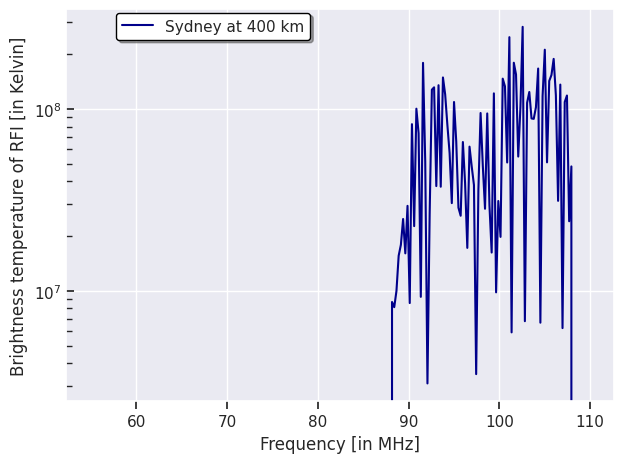

In [27]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})

plt.plot(freq_range,power_output[0,2363,:], label='Sydney at 400 km', color='darkblue') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)

# plt.savefig("/home/sonia/Documents/RFI_PAPER/Sydney_400_new.pdf")

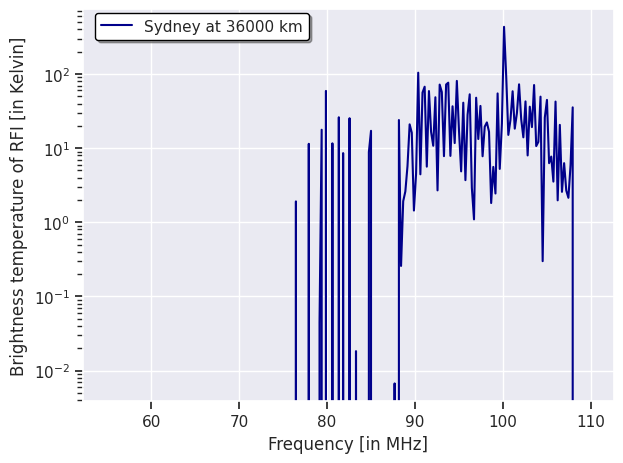

In [28]:
import seaborn as sns
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True})

plt.plot(freq_range,power_output[2,2363,:], label='Sydney at 36000 km', color='darkblue') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.44, 1.01),fancybox=True, shadow=True)
# plt.savefig("/home/sonia/Documents/RFI_PAPER/Sydney_36000_new.pdf")

## Plot Healpy map of brightness temperature of RFI 

In [29]:
test_plot = np.zeros(hp.nside2npix(nside))
test_plot[0:np.size(power_output[0,:,185])] = power_output[0,:,185]

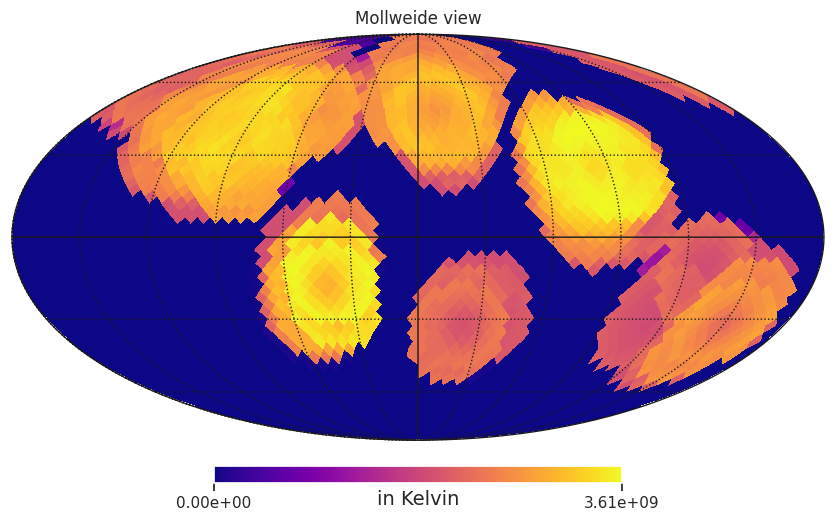

In [30]:
#from healpy.newvisufunc import projview, newprojplot
hp.mollview(test_plot,cmap='plasma',unit="in Kelvin",flip='geo',norm="hist",format= '%.2e')
hp.graticule()
sns.set(font_scale=2)
#plt.rcParams.update({'font.size': 105}) # fontsize for colorbar's values

#fontsize = 22
#plt.savefig("/home/sonia/Documents/RFI_PAPER/heatmap400_107_new.pdf")

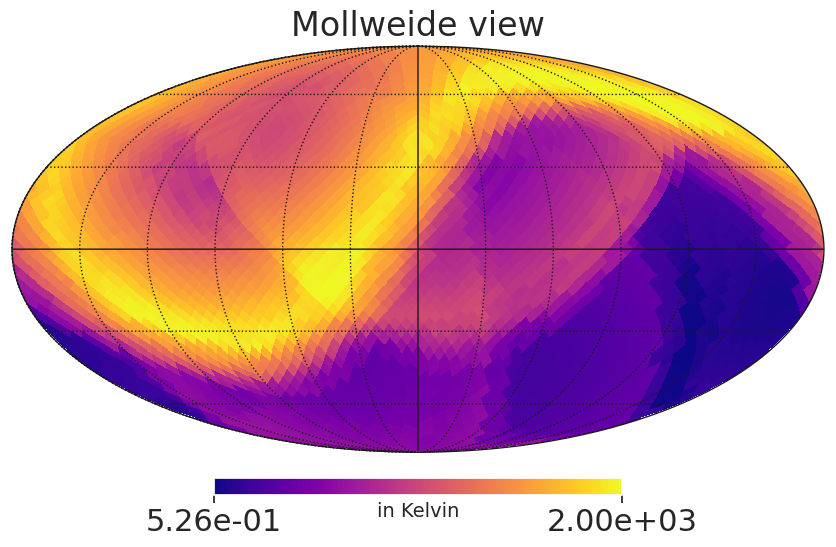

In [31]:

test_plot1 = np.zeros(hp.nside2npix(nside)) 
test_plot1[0:np.size(power_output[2,:,144])] = power_output[2,:,144]
#hp.mollview(healpix_map,cmap='YlGnBu', xsize=2000, flip="geo")
#hp.graticule()
hp.mollview(test_plot1,cmap='plasma',unit="in Kelvin",flip='geo',norm='hist',format= '%.2e')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')

hp.graticule()
#cmap = copy.copy(mpl.cm.get_cmap("inferno"))
#newcm.set_over(newcm(1.0))

In [32]:
freq_range[144]

90.13599999999997

## Creating an Nside 16 map of Global Pop Dens

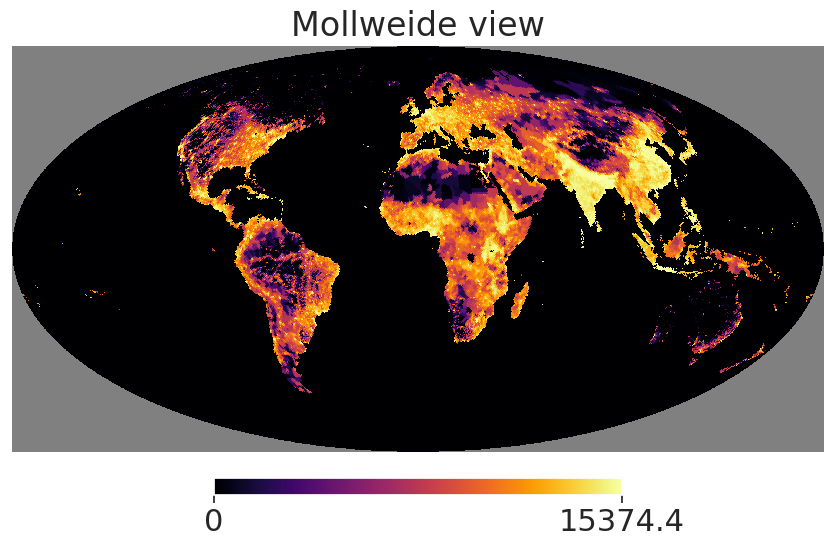

In [33]:
##import libraries##
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import healpy as hp

##Read the tif file##
image = tiff.imread('/media/sf_Shared_Ubuntu/MAPS/gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif')
image_array = np.array(image)


# Define the spherical coordinates#
theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1],endpoint=False)

# Set angular resolution#
nside = 128

## Make empty healpix mask and pixel values vector##
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)


for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

# Average value of each pixel#
healpix_map[pixel_counts>0] /= pixel_counts[pixel_counts>0 ]


hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
plt.show()





## Verify coordinate system of GEOTIFF file

In [34]:
import rasterio

# Path to your GeoTIFF file
geotiff_file = '/media/sf_Shared_Ubuntu/MAPS/gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif'

# Open the GeoTIFF file
with rasterio.open(geotiff_file) as dataset:
    # Get metadata
    metadata = dataset.meta

    # Get CRS (Coordinate Reference System)
    crs = dataset.crs

    # Get image dimensions (width and height)
    width = dataset.width
    height = dataset.height

    # Get transformation parameters (geotransform)
    geotransform = dataset.transform

# Print metadata
print("Metadata:")
print(metadata)

# Print CRS
print("\nCoordinate Reference System (CRS):")
print(crs)

# Print image dimensions
print("\nImage Dimensions:")
print("Width:", width)
print("Height:", height)

# Print geotransformation parameters
print("\nGeotransformation Parameters:")
print("Affine Transformation Matrix:\n\n", geotransform)


Metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.4028230607370965e+38, 'width': 1440, 'height': 720, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.250000000000016, 0.0, -180.0,
       0.0, -0.250000000000016, 90.0000000000116)}

Coordinate Reference System (CRS):
EPSG:4326

Image Dimensions:
Width: 1440
Height: 720

Geotransformation Parameters:
Affine Transformation Matrix:

 | 0.25, 0.00,-180.00|
| 0.00,-0.25, 90.00|
| 0.00, 0.00, 1.00|


## creating nside 128 maps of STARFIRE Tx database

In [35]:


file_paths = ["./database/UK_final.csv","./database/Australia.csv","./database/India.csv","./database/Italy.csv","./database/Canada.csv"]


df_128 = []
for file_path in file_paths:
    df_temp = pd.read_csv(file_path)
    df_128.append(df_temp)


# lat_128=df[]
# lon_128=df['Longitude in degrees'].to_numpy()
# power_128=df['EIRP'].to_numpy()
# pixel_128=hp.ang2pix(128,lon_128,lat_128,lonlat=True)



In [36]:
import healpy as hp
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
# Get a list of all CSV files in a directory

# Get a list of all CSV files in the "./database" directory
csv_files = glob.glob('./database/*.csv')

# Exclude the "Brazil.csv" file from the list
csv_files = [file for file in csv_files if not file.endswith('Brazil.csv')]

# Now, csv_files will contain a list of CSV files in the "./database" directory except for "Brazil.csv"


# Create an empty dataframe to store the combined data
combined_df = pd.DataFrame()

# Loop through each CSV file and append its contents to the combined dataframe
for csv_file in csv_files:
    df_temp = pd.read_csv(csv_file)
    combined_df = pd.concat([combined_df, df_temp])

# Print the combined dataframe
lat_128=combined_df['Latitude in degrees'].to_numpy()
lon_128=combined_df['Longitude in degrees'].to_numpy()
power_128=combined_df['EIRP'].to_numpy()
pixel_128=hp.ang2pix(128,lon_128,lat_128,lonlat=True)

## Num of Tx map

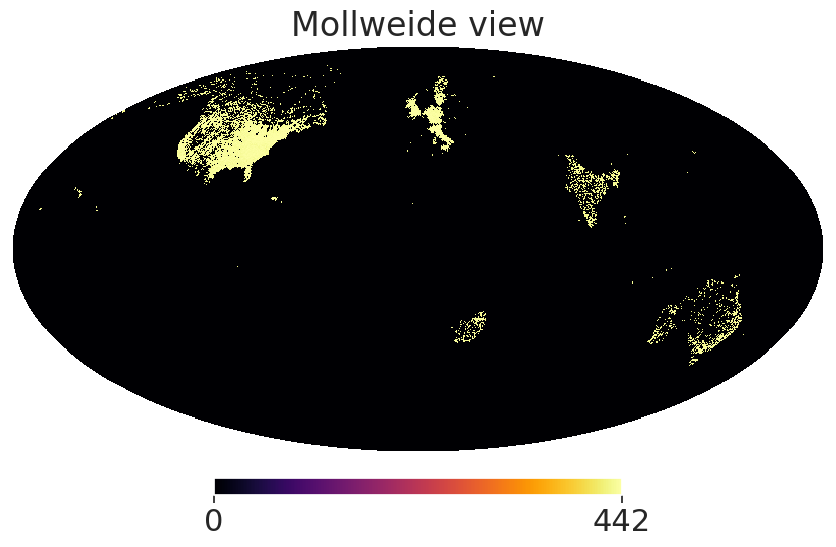

In [37]:
Tx_num_128=np.zeros(hp.nside2npix(128))
for pix in pixel_128:
    Tx_num_128[pix]+=1
hp.mollview(Tx_num_128,flip='geo',min=0,cmap='inferno',norm='hist')
plt.show()

## Tx power map

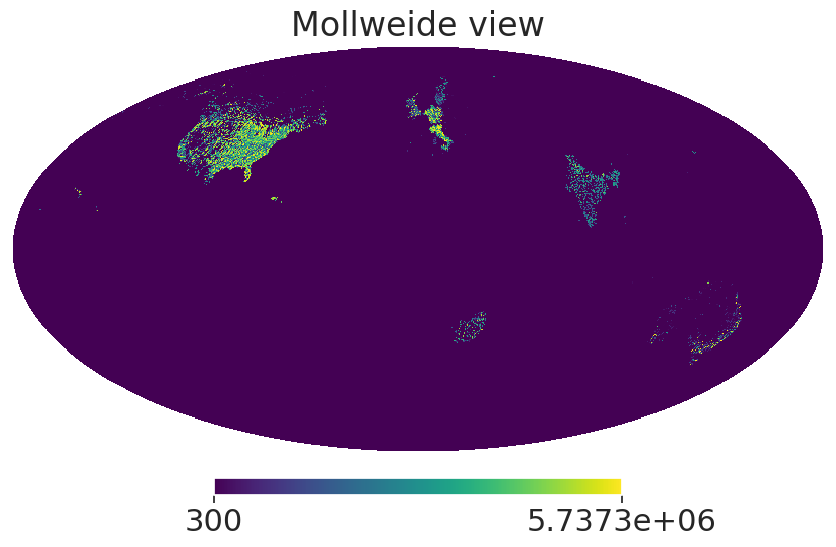

In [38]:
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(pixel_128):
    Tx_pow_128[p]+=(power_128[index])
hp.mollview(Tx_pow_128,flip='geo',min=3*10**2,cmap='viridis',norm='hist')
plt.show()

In [39]:
# hp.mollview(healpix_map, cmap="inferno", xsize=3000, flip="geo", norm="hist", min=0)
# hp.mollview(Tx_num_128,flip='geo',min=0,cmap='inferno',norm='hist')
# hp.mollview(Tx_pow_128,flip='geo',min=3*10**4,cmap='viridis',norm='hist')

# degraded_trial=hp.ud_grade(healpix_map,16)
# # hp.mollview(degraded_trial,flip='geo',norm='hist',min=0)
# plt.show()

In [40]:
# # x_=healpix_map
# # y_=Tx_num_128
# br_df=pd.read_csv('./database/India.csv')
# br_lon=br_df['Longitude in degrees'].to_numpy()
# br_lat=br_df['Latitude in degrees'].to_numpy()
# selected_indices=hp.ang2pix(128,br_lon,br_lat,lonlat=True)
# color=[]
# for pix,_ in enumerate(x_):
#     if pix in selected_indices:
#         color.append('r')
#     else:
#         color.append('g')


# plt.scatter(x_,y_,marker="*",c=color,linewidths=0.1)
# fin_val_index=(x_>0)&(y_>0)
# # x_=x_[fin_val_index]
# # y_=y_[fin_val_index]

# # plt.scatter(x_,y_,marker="*",linewidths=0.1)
# plt.xscale('log')
# # plt.yscale('log')
# plt.show()

In [41]:
selected_indices=[]
healpix_map[healpix_map<1e-3]=0
x_=healpix_map
y_=Tx_pow_128
fin_val_index=(x_>0)&(y_>0)
# x_=x_[fin_val_index]
# y_=y_[fin_val_index]
c1_df=pd.read_csv('./database/India.csv')
c1_lon=c1_df['Longitude in degrees'].to_numpy()
c1_lat=c1_df['Latitude in degrees'].to_numpy()
selected_indices1=hp.ang2pix(128,br_lon,br_lat,lonlat=True)

c2_df=pd.read_csv('./database/updated_USA_file_final.csv')
c2_lon=c2_df['Longitude in degrees'].to_numpy()
c2_lat=c2_df['Latitude in degrees'].to_numpy()
selected_indices2=hp.ang2pix(128,br_lon,br_lat,lonlat=True)

c3_df=pd.read_csv('./database/UK_final.csv')
c3_lon=c3_df['Longitude in degrees'].to_numpy()
c3_lat=c3_df['Latitude in degrees'].to_numpy()
selected_indices3=hp.ang2pix(128,br_lon,br_lat,lonlat=True)
color=[]
for pix,_ in enumerate(x_):
    if pix in selected_indices1:
        color.append('r')
    elif pix in selected_indices2:
        color.append('g')
    elif pix in selected_indices3:
        color.append('b')
    else:
        color.append('y')
            
    


plt.scatter(x_,y_,marker="1",c=color,linewidths=0.7)
plt.xscale('log')
plt.yscale('log')
# plt.xlim(left=100)
plt.show()

NameError: name 'br_lon' is not defined

In [ ]:
plt.hist(y_[y_!=0],bins=np.linspace(1e1,1e6,500),color='r')
# plt.xscale('log')
plt.show()

In [48]:

c1_df=pd.read_csv('./database/India.csv')
c1_lon=c1_df['Longitude in degrees'].to_numpy()
c1_lat=c1_df['Latitude in degrees'].to_numpy()
selected_indices1=hp.ang2pix(128,c1_lon,c1_lat,lonlat=True)

c2_df=pd.read_csv('./database/updated_USA_file_final.csv')
c2_lon=c2_df['Longitude in degrees'].to_numpy()
c2_lat=c2_df['Latitude in degrees'].to_numpy()
selected_indices2=hp.ang2pix(128,c2_lon,c2_lat,lonlat=True)

c3_df=pd.read_csv('./database/UK_final.csv')
c3_lon=c3_df['Longitude in degrees'].to_numpy()
c3_lat=c3_df['Latitude in degrees'].to_numpy()
selected_indices3=hp.ang2pix(128,c3_lon,c3_lat,lonlat=True)


c4_df=pd.read_csv('./database/updated_file_sweden.csv')
c4_lon=c4_df['Longitude in degrees'].to_numpy()
c4_lat=c4_df['Latitude in degrees'].to_numpy()
selected_indices4=hp.ang2pix(128,c4_lon,c4_lat,lonlat=True)

c1_df=pd.read_csv('./database/India.csv')
c1_lon=c1_df['Longitude in degrees'].to_numpy()
c1_lat=c1_df['Latitude in degrees'].to_numpy()
selected_indices1=hp.ang2pix(128,c1_lon,c1_lat,lonlat=True)

c2_df=pd.read_csv('./database/updated_USA_file_final.csv')
c2_lon=c2_df['Longitude in degrees'].to_numpy()
c2_lat=c2_df['Latitude in degrees'].to_numpy()
selected_indices2=hp.ang2pix(128,c2_lon,c2_lat,lonlat=True)

c3_df=pd.read_csv('./database/UK_final.csv')
c3_lon=c3_df['Longitude in degrees'].to_numpy()
c3_lat=c3_df['Latitude in degrees'].to_numpy()
selected_indices3=hp.ang2pix(128,c3_lon,c3_lat,lonlat=True)


c4_df=pd.read_csv('./database/updated_file_sweden.csv')
c4_lon=c4_df['Longitude in degrees'].to_numpy()
c4_lat=c4_df['Latitude in degrees'].to_numpy()
selected_indices4=hp.ang2pix(128,c4_lon,c4_lat,lonlat=True)

c5_df=pd.read_csv('./database/Germany.csv')
c5_lon=c5_df['Longitude in degrees'].to_numpy()
c5_lat=c5_df['Latitude in degrees'].to_numpy()
selected_indices5=hp.ang2pix(128,c5_lon,c5_lat,lonlat=True)
color=[]
for pix,_ in enumerate(x_):
    if pix in selected_indices1:
        color.append('r')
    elif pix in selected_indices2:
        color.append('g')
    elif pix in selected_indices3:
        color.append('b')
    elif pix in selected_indices4:
        color.append('purple')
    elif pix in selected_indices5:
        color.append('cyan')
    else:
        color.append('y')


In [49]:
color

['y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y',
 'y'

In [42]:
csv_files = glob.glob('./database/*.csv')


csv_files = [file for file in csv_files if not file.endswith('Brazil.csv')]




# Create an empty dataframe to store the combined data
combined_df = pd.DataFrame()

# Loop through each CSV file and append its contents to the combined dataframe
for csv_file in csv_files:
    df_temp = pd.read_csv(csv_file)
    combined_df = pd.concat([combined_df, df_temp])

# Print the combined dataframe
lat_12=combined_df['Latitude in degrees'].to_numpy()
lon_12=combined_df['Longitude in degrees'].to_numpy()
power_12=combined_df['EIRP'].to_numpy()
pixel_12=hp.ang2pix(128,lon_128,lat_128,lonlat=True)

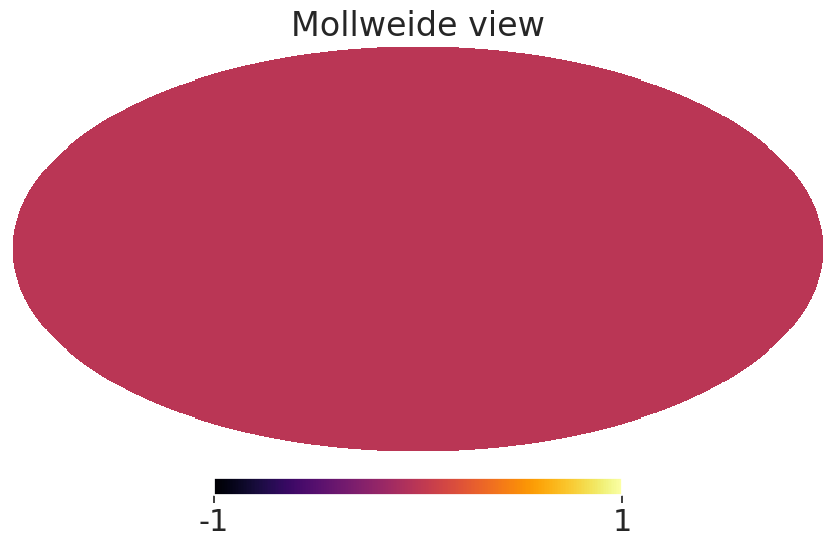

In [44]:
Tx_num_12=np.zeros(hp.nside2npix(128))
for pix in pixel_12:
    Tx_num_12[pix]+=1
Tx_diffmap=Tx_num_12-Tx_num_128
hp.mollview(Tx_diffmap,flip='geo',cmap='inferno',norm='hist')
plt.show()

In [50]:
np.count_nonzero(Tx_diffmap)

0